# EMTA andmete analüüs

## Ettevalmistused

In [1]:
from typing import Callable

import pandas as pd
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns

## Andmetega tutvumine

In [ ]:
data_raw_this_year = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv", nrows=5) # näitame ainult 5 rida
data_raw_this_year

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,10.04.2026,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,1723565,2038192.0,2141341.0,...,1213643.0,1131417.0,34309154,30413704.0,23282177.0,21724706.0,254.0,243.0,244.0,240.0
1,10.04.2026,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2026,1561762,NaN,NaN,...,NaN,NaN,19993085,NaN,NaN,NaN,236.0,NaN,NaN,NaN
2,10.04.2026,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2025,40888,41980.0,38723.0,...,38979.0,36127.0,236677,235518.0,206299.0,280010.0,11.0,11.0,10.0,10.0
3,10.04.2026,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2026,48644,NaN,NaN,...,NaN,NaN,299247,NaN,NaN,NaN,11.0,NaN,NaN,NaN
4,10.04.2026,10000062,ALDO KOPPEL,FIE,Ida-Viru ( Lüganuse vald ),"PÕLLUMAJANDUS, METSAMAJANDUS JA KALAPÜÜK",2025,313,342.0,635.0,...,0.0,NaN,1941,2925.0,9273.0,906.0,NaN,NaN,NaN,NaN


In [ ]:
duckdb.sql("""
    from 'tasutud_maksud_varasemad_aastad.csv'
    LIMIT 5
""").df()

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2022,<NA>,288,<NA>,...,<NA>,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2023,<NA>,288,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,2026-04-10,01834351,"LOMBI-13, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2024,288,52,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,2026-04-10,01834575,"KUNDERI 24, GARAAŽIKOOPERATIIV",Äriühing,Harju ( Tallinn ),NaN,2024,<NA>,<NA>,268,...,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2022,1300554,1645555,1185273,...,923188,950362,22930261,31976194,26140614,31599227,214,228,231,232


In [ ]:
# Kontrollime kas tulpade nimed on mõlemas failis samad
data_raw_new = pd.read_csv("tasutud_maksud_kaesolev_aasta.csv", nrows=5)
data_raw_old = pd.read_csv("tasutud_maksud_varasemad_aastad.csv", nrows=5)

data_raw_new.columns == data_raw_old.columns

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [ ]:
data_raw = duckdb.sql("""
    from 'tasutud_maksud_kaesolev_aasta.csv'
    union all
    from 'tasutud_maksud_varasemad_aastad.csv'
""").df()
data_raw

,Andmete seis,Registrikood,Nimi,Liik,Maakond,Tegevusala,Aasta,Riiklikud maksud I kv,Riiklikud maksud II kv,Riiklikud maksud III kv,...,Tööjõumaksud III kv,Tööjõumaksud IV kv,Käive I kv,Käive II kv,Käive III kv,Käive IV kv,Töötajate arv I kv,Töötajate arv II kv,Töötajate arv III kv,Töötajate arv IV kv
0,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2025,1723565,2038192,2141341,...,1213643,1131417,34309154,30413704,23282177,21724706,254,243,244,240
1,2026-04-10,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju ( Tallinn ),HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2026,1561762,<NA>,<NA>,...,<NA>,<NA>,19993085,<NA>,<NA>,<NA>,236,<NA>,<NA>,<NA>
2,2026-04-10,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2025,40888,41980,38723,...,38979,36127,236677,235518,206299,280010,11,11,10,10
3,2026-04-10,10000024,"EESTI RAAMAT, OÜ",Äriühing,Harju ( Tallinn ),INFO JA SIDE,2026,48644,<NA>,<NA>,...,<NA>,<NA>,299247,<NA>,<NA>,<NA>,11,<NA>,<NA>,<NA>
4,2026-04-10,10000062,ALDO KOPPEL,FIE,Ida-Viru ( Lüganuse vald ),"PÕLLUMAJANDUS, METSAMAJANDUS JA KALAPÜÜK",2025,313,342,635,...,0,<NA>,1941,2925,9273,906,<NA>,<NA>,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1070347,2026-04-10,OO000012,HANDELSBOLAGET KORSVÄGEN FÖRVALTING,Mitteresident,NaN,NaN,2024,2,13,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1070348,2026-04-10,OO000015,TRUST FINANCING AB,Mitteresident,NaN,NaN,2024,<NA>,83,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1070349,2026-04-10,QQ000003,RAUMASTER OY,Mitteresident,NaN,HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2022,24114,18514,21953,...,21802,22937,26908,26851,86902,23302,3,3,3,3
1070350,2026-04-10,QQ000003,RAUMASTER OY,Mitteresident,NaN,HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...,2023,23447,20816,23767,...,24487,23491,18309,19522,7596,47353,3,3,3,4


In [ ]:
data_unpivot = duckdb.sql("""
WITH base AS (
    SELECT
        "Andmete seis",
        "Registrikood",
        "Nimi",
        "Liik",
        "Maakond",
        "Tegevusala",
        "Aasta",
        "Riiklikud maksud I kv" AS riiklikud_maksud_1,
        "Riiklikud maksud II kv" AS riiklikud_maksud_2,
        "Riiklikud maksud III kv" AS riiklikud_maksud_3,
        "Riiklikud maksud IV kv" AS riiklikud_maksud_4,
        "Tööjõumaksud I kv" AS toojou_maksud_1,
        "Tööjõumaksud II kv" AS toojou_maksud_2,
        "Tööjõumaksud III kv" AS toojou_maksud_3,
        "Tööjõumaksud IV kv" AS toojou_maksud_4,
        "Käive I kv" AS kaive_1,
        "Käive II kv" AS kaive_2,
        "Käive III kv" AS kaive_3,
        "Käive IV kv" AS kaive_4,
        "Töötajate arv I kv" AS tootajad_1,
        "Töötajate arv II kv" AS tootajad_2,
        "Töötajate arv III kv" AS tootajad_3,
        "Töötajate arv IV kv" AS tootajad_4
    FROM data_raw
)
UNPIVOT base
ON
    (riiklikud_maksud_1, toojou_maksud_1, kaive_1, tootajad_1),
    (riiklikud_maksud_2, toojou_maksud_2, kaive_2, tootajad_2),
    (riiklikud_maksud_3, toojou_maksud_3, kaive_3, tootajad_3),
    (riiklikud_maksud_4, toojou_maksud_4, kaive_4, tootajad_4)
INTO
    NAME kvartal
    VALUE riiklikud_maksud, toojoumaksud, kaive, tootajate_arv;
""")
data_unpivot

┌─────────────────────┬──────────────┬─────────────────────────┬──────────┬─────────────────────────────┬─────────────────────────────────────────────────────────────────┬───────┬───────────────────────────────────────────────────────┬──────────────────┬──────────────┬──────────┬───────────────┐
│    Andmete seis     │ Registrikood │          Nimi           │   Liik   │           Maakond           │                           Tegevusala                            │ Aasta │                        kvartal                        │ riiklikud_maksud │ toojoumaksud │  kaive   │ tootajate_arv │
│      timestamp      │   varchar    │         varchar         │ varchar  │           varchar           │                             varchar                             │ int64 │                        varchar                        │      int64       │    int64     │  int64   │     int64     │
├─────────────────────┼──────────────┼─────────────────────────┼──────────┼─────────────────────────────┼────

In [ ]:
def eralda_maakond(maakond: str) -> str:
    return maakond.split(" ( ")[0]

def eralda_kov(maakond: str) -> str:
    return maakond.split(" ( ")[1][:-2]
    # return maakond.split(" ( ")[1].replace(" )","") see on alternatiiv variant

def eralda_kvartal(kvartal: str) -> int:
    return int(kvartal[-1])

def peamine_tegevusala(tegevusala: str) -> str:
    return tegevusala.split(";")[0]

def _register_duckdb_function(duckdb_function_name: str, function: Callable) -> None:
    try:
        duckdb.remove_function(duckdb_function_name)
    except:
        pass
    duckdb.create_function(duckdb_function_name, function)

_register_duckdb_function(duckdb_function_name="eralda_maakond", function=eralda_maakond)
_register_duckdb_function(duckdb_function_name="eralda_kov", function=eralda_kov)
_register_duckdb_function(duckdb_function_name="eralda_kvartal", function=eralda_kvartal)
_register_duckdb_function(duckdb_function_name="peamine_tegevusala", function=peamine_tegevusala);

In [ ]:
peamine_tegevusala("HULGI- JA JAEKAUBANDUS; MOOTORSÕIDUKITE JA MOO...")

'HULGI- JA JAEKAUBANDUS'

In [ ]:
eralda_kvartal("riiklikud_maksud_1_toojou_maksud_1_kaive_1_tootajad_1")

1

In [ ]:
eralda_kov("Harju ( Tallinn )")

'Tallinn'

In [ ]:
data = duckdb.sql("""
    SELECT
           Registrikood AS registrikood,
           Nimi AS nimi,
           Liik AS liik,
           eralda_maakond(Maakond) AS maakond,
           eralda_kov(Maakond) AS kov,
           peamine_tegevusala(Tegevusala) AS tegevusala,
           Aasta AS aasta,
           eralda_kvartal(Kvartal) AS kvartal,
           riiklikud_maksud,
           toojoumaksud,
           kaive,
           tootajate_arv
    FROM data_unpivot
""").df()
data # sellega anname andmebaasile puhastatud nime "data", eelnevad olid "raw" jne

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,registrikood,nimi,liik,maakond,kov,tegevusala,aasta,kvartal,riiklikud_maksud,toojoumaksud,kaive,tootajate_arv
0,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,1,1723565,1259900,34309154,254
1,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,2,2038192,1229742,30413704,243
2,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,3,2141341,1213643,23282177,244
3,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,4,1844403,1131417,21724706,240
4,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2026,1,1561762,1088007,19993085,236
...,...,...,...,...,...,...,...,...,...,...,...,...
943929,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2023,4,22804,23491,47353,4
943930,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,1,31928,33059,99940,4
943931,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,2,25677,26511,5551,4
943932,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,3,27572,28496,0,4


## Avastuslik andmeanalüüs (exploratory analysis)

In [ ]:
duckdb.sql("""
    SUMMARIZE data
""")

┌──────────────────┬─────────────┬──────────────────────────────────────────────────────────────┬────────────────────┬───────────────┬────────────────────┬────────────────────┬─────────┬─────────┬─────────┬────────┬─────────────────┐
│   column_name    │ column_type │                             min                              │        max         │ approx_unique │        avg         │        std         │   q25   │   q50   │   q75   │ count  │ null_percentage │
│     varchar      │   varchar   │                           varchar                            │      varchar       │     int64     │      varchar       │      varchar       │ varchar │ varchar │ varchar │ int64  │  decimal(9,2)   │
├──────────────────┼─────────────┼──────────────────────────────────────────────────────────────┼────────────────────┼───────────────┼────────────────────┼────────────────────┼─────────┼─────────┼─────────┼────────┼─────────────────┤
│ registrikood     │ VARCHAR     │ 10000018                     

## Kui palju on ettevõtteid ja mis on keskmine käive maakonniti 2026 aasta I kvartalis

In [ ]:
duckdb.sql("""
    SELECT
           maakond,
           count(distinct registrikood) AS ettevõtete_arv,
           round(avg(kaive)/3)::int AS keskmine_kuine_kaive,
           round(avg(kaive))::int AS keskmine_kvartaalne_kaive
    FROM data
    WHERE aasta = 2026 AND kvartal = 1
    GROUP BY maakond
    ORDER BY keskmine_kuine_kaive DESC
""")

┌────────────┬────────────────┬──────────────────────┬───────────────────────────┐
│  maakond   │ ettevõtete_arv │ keskmine_kuine_kaive │ keskmine_kvartaalne_kaive │
│  varchar   │     int64      │        int32         │           int32           │
├────────────┼────────────────┼──────────────────────┼───────────────────────────┤
│ NULL       │            141 │               254183 │                    762548 │
│ Harju      │          31202 │               201933 │                    605799 │
│ Järva      │            936 │               124710 │                    374131 │
│ Tartu      │           6616 │               120512 │                    361536 │
│ Lääne-Viru │           2095 │               105897 │                    317690 │
│ Viljandi   │           1723 │                88801 │                    266402 │
│ Valga      │            839 │                81555 │                    244664 │
│ Jõgeva     │            949 │                80395 │                    241184 │
│ Id

## Joonistame graafiku tegevusalade ja tõõtajate võrdluseks

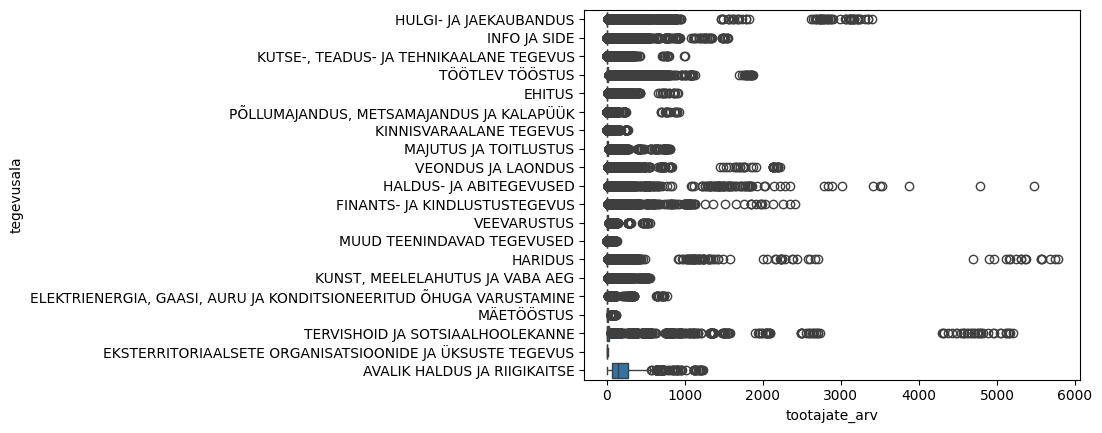

In [ ]:
sns.boxplot(data, y = "tegevusala", x = "tootajate_arv"); # andmete jaotus on proportsioonist välja, enamus on väiksed ettevõtted ja üksikud ülisuured, mis tekitab loetavuse probleemi

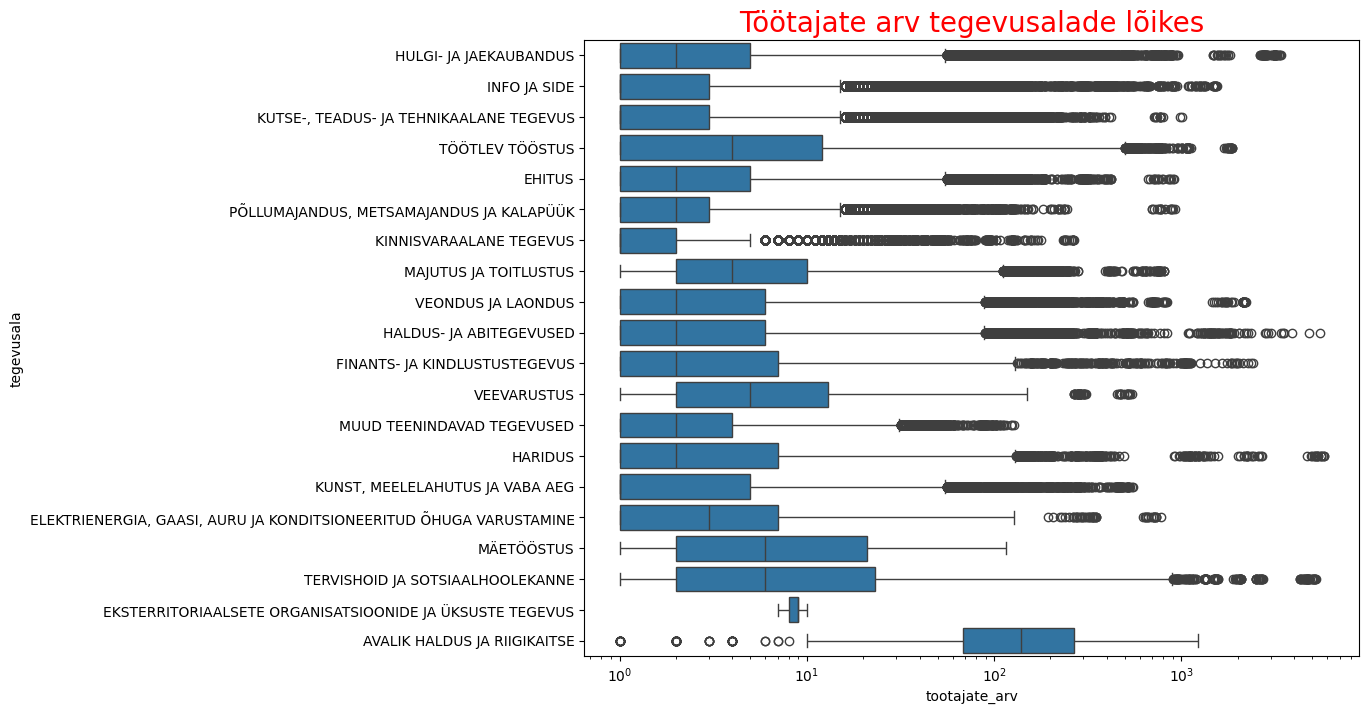

In [ ]:
plt.figure(1, figsize=(10, 8)) # tabeli suuruse muutmine
sns.boxplot(data, y = "tegevusala", x = "tootajate_arv", log_scale=10)
plt.title("Töötajate arv tegevusalade lõikes", size=20, color="red", loc="center"); # Tabelile nime andmine
# ax = ...
# ax.set_xscale('log') teine variant logaritmilise tabeli loomiseks

In [ ]:
data.to_csv("emta_data.csv", index=False)

## Töötajate ja käibe suhe

In [2]:
data=pd.read_csv("emta_data.csv")
data

C:\Users\opilane\AppData\Local\Temp\ipykernel_14296\3530606680.py:1: DtypeWarning: Columns (0: registrikood) have mixed types. Specify dtype option on import or set low_memory=False.
  data=pd.read_csv("emta_data.csv")


,registrikood,nimi,liik,maakond,kov,tegevusala,aasta,kvartal,riiklikud_maksud,toojoumaksud,kaive,tootajate_arv
0,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,1,1723565,1259900,34309154,254
1,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,2,2038192,1229742,30413704,243
2,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,3,2141341,1213643,23282177,244
3,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2025,4,1844403,1131417,21724706,240
4,10000018,AMSERV AUTO OSAÜHING,Äriühing,Harju,Tallinn,HULGI- JA JAEKAUBANDUS,2026,1,1561762,1088007,19993085,236
...,...,...,...,...,...,...,...,...,...,...,...,...
943929,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2023,4,22804,23491,47353,4
943930,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,1,31928,33059,99940,4
943931,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,2,25677,26511,5551,4
943932,QQ000003,RAUMASTER OY,Mitteresident,NaN,NaN,HULGI- JA JAEKAUBANDUS,2024,3,27572,28496,0,4


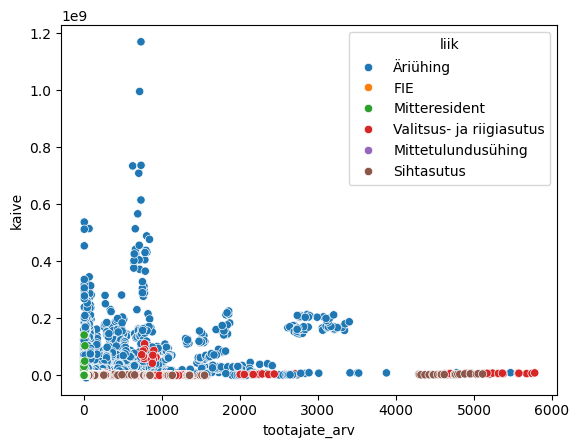

In [17]:
sns.scatterplot(data, x="tootajate_arv", y="kaive", hue="liik");

In [21]:
avg_revenue = duckdb.sql("""
    SELECT
        nimi,
        avg(round(kaive / 3))::int AS avg_kaive,
        avg(round(tootajate_arv))::int AS tootajate_arv,
        any_value(liik) AS liik,
        any_value(maakond) AS maakond
    FROM data
    GROUP BY nimi
    ORDER BY avg_kaive DESC
""").df()
avg_revenue

,nimi,avg_kaive,tootajate_arv,liik,maakond
0,EESTI ENERGIA AS,191064034,685,Äriühing,Harju
1,BOLT OPERATIONS OÜ,117072399,773,Äriühing,Harju
2,ORLEN EESTI OÜ,107338365,7,Äriühing,Harju
3,AS ELENGER GRUPP,85115652,80,Äriühing,Harju
4,TOYOTA BALTIC AS,73011311,43,Äriühing,Harju
...,...,...,...,...,...
80884,SMALLMIX OÜ,-5273,2,Äriühing,Harju
80885,KE KONSULT OÜ,-7337,2,Äriühing,Harju
80886,24/7 KAUBANDUS OÜ,-15756,4,Äriühing,Harju
80887,PROFI LOGISTIC OÜ,-15985,1,Äriühing,Harju


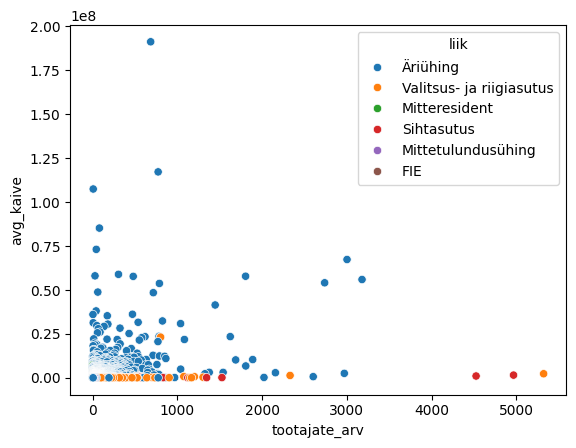

In [15]:
sns.scatterplot(avg_revenue, x="tootajate_arv", y="avg_kaive", hue="liik");

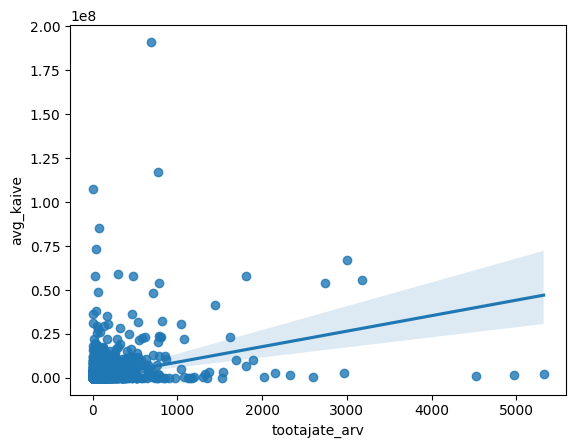

In [20]:
sns.regplot(avg_revenue, x="tootajate_arv", y="avg_kaive");

In [22]:
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    duckdb.sql("SELECT avg_kaive FROM avg_revenue WHERE maakond = 'Tartu' AND avg_kaive IS NOT NULL").df()["avg_kaive"],
    duckdb.sql("SELECT avg_kaive FROM avg_revenue WHERE maakond = 'Pärnu' AND avg_kaive IS NOT NULL").df()["avg_kaive"],
    alternative='two-sided'
)
float(p)
print(f"{p:.15f}")

0.000000000058441
